In [5]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor.tensor as pt

import warnings
warnings.filterwarnings('ignore')

In [10]:
def f_2(x):
            return (1 - x) ** 4

def f_3(x):
    term1 = 1 / (x * np.sqrt(3 * np.pi))
    exponent = -0.5 * ((np.log(x) + np.sqrt(1.5) - np.log(3)) ** 2)
    return term1 * np.exp(exponent)

def f_4(x):
    return f_3(1 - x)

def f_5(x):
    return f_2(1 - x)

In [11]:
def create_bipartite_bayesian_network_vectorized(
    ratings_matrix,
    student_alpha=2, student_beta=2,
    item_alpha=2, item_beta=2,
    draws=1000, tune=1000, chains=2, cores=2,
):
    
    def f_2(x):
            return (1 - x) ** 4

    def f_3(x):
        term1 = 1 / (x * pm.math.sqrt(3 * np.pi))
        exponent = -0.5 * ((pm.math.log(x) + pm.math.sqrt(1.5) - pm.math.log(3)) ** 2)
        return term1 * pm.math.exp(exponent)

    def f_4(x):
        return f_3(1 - x)

    def f_5(x):
        return f_2(1 - x)

    n_students, n_items = ratings_matrix.shape

    obs_rows, obs_cols = np.where(~np.isnan(ratings_matrix))
    obs_ratings = ratings_matrix[obs_rows, obs_cols].astype(int)
    n_obs = len(obs_ratings)

    if n_obs == 0:
        raise ValueError("No observed ratings (all NaN).")
    
    obs_shifted = obs_ratings - 2

    with pm.Model() as bipartite_model:
        # Latent variables (vectorized)
        student_ability = pm.Beta("student_ability",
                                  alpha=student_alpha, beta=student_beta,
                                  shape=n_students)
        item_difficulty = pm.Beta("item_difficulty",
                                  alpha=item_alpha, beta=item_beta,
                                  shape=n_items)
        
    
        a = student_ability[obs_rows]
        d = item_difficulty[obs_cols]
        ratio = (a / (a + d))

        eps = 1e-12
        ratio_clip = pt.clip(ratio, eps, 1 - eps)

        p2 = f_2(ratio_clip)
        p3 = f_3(ratio_clip)
        p4 = f_4(ratio_clip)
        p5 = f_5(ratio_clip)

        else_probs_raw = pt.stack([p2, p3, p4, p5], axis=1)
        else_probs = else_probs_raw / else_probs_raw.sum(axis=1, keepdims=True)

        const_5 = pt.as_tensor_variable([0.001, 0.001, 0.001, 0.997])
        const_2 = pt.as_tensor_variable([0.997, 0.001, 0.001, 0.001])


        # p_const_5 = pt.ones((n_obs, 1)) * const_5
        # p_const_2 = pt.ones((n_obs, 1)) * const_2
    
        # cond_to_get_5 = a > (0.8 + d * 0.2)
        # cond_to_get_2 = a < (d * 0.2)

        # cond_to_get_5_col = cond_to_get_5[:, None]
        # cond_to_get_2_col = cond_to_get_2[:, None]

        temp = 30.0

        logit_5 = temp * (a - (0.8 + 0.2 * d))
        logit_2 = temp * ((0.2 * d) - a)

        p_extreme_5 = pm.math.sigmoid(logit_5)
        p_extreme_2 = pm.math.sigmoid(logit_2)

        total_extreme = p_extreme_5 + p_extreme_2
        p_5 = p_extreme_5 / (total_extreme + 1e-8)
        p_2 = p_extreme_2 / (total_extreme + 1e-8)
        p_middle = 1.0 - p_5 - p_2

        prob_vec = (p_5[:, None] * const_5[None, :]) + \
           (p_2[:, None] * const_2[None, :]) + \
           (p_middle[:, None] * else_probs)

        # prob_vec = pm.math.switch(
        #     cond_to_get_5_col,
        #     p_const_5,
        #     pm.math.switch(cond_to_get_2_col, p_const_2, else_probs)
        # )

        pm.Categorical("ratings_obs", p=prob_vec, observed=obs_shifted)

        trace = pm.sample(
            draws=draws, tune=tune, chains=chains, cores=cores,
            target_accept=0.95, return_inferencedata=True, max_tree_depth=30
        )

    return trace, bipartite_model

In [80]:
def create_bipartite_bayesian_network_good(ratings_matrix, student_alpha=2, student_beta=2,
                                      item_alpha=2, item_beta=2,
                                      draws=1000, tune=1000, chains=2, cores=2):
      def f_2(x):
                  return (1 - x) ** 4

      def f_3(x):
            term1 = 1 / (x * pm.math.sqrt(3 * np.pi))
            exponent = -0.5 * ((pm.math.log(x) + pm.math.sqrt(1.5) - pm.math.log(3)) ** 2)
            return term1 * pm.math.exp(exponent)

      def f_4(x):
            return f_3(1 - x)

      def f_5(x):
            return f_2(1 - x)

      n_students, n_items = ratings_matrix.shape

      obs_rows, obs_cols = np.where(~np.isnan(ratings_matrix))
      obs_ratings = ratings_matrix[obs_rows, obs_cols].astype(int)
      n_obs = len(obs_ratings)

      if n_obs == 0:
            raise ValueError("No observed ratings (all NaN).")

      obs_shifted = obs_ratings - 2

      with pm.Model() as bipartite_model:
            # Latent variables (vectorized)
            student_ability = pm.Beta("student_ability",
                                    alpha=student_alpha, beta=student_beta,
                                    shape=n_students)
            item_difficulty = pm.Beta("item_difficulty",
                                    alpha=item_alpha, beta=item_beta,
                                    shape=n_items)
      
            a = student_ability[obs_rows]
            d = item_difficulty[obs_cols]
            ratio = (a / (a + d))

            eps = 1e-12
            ratio_clip = pt.clip(ratio, eps, 1 - eps)

            p2 = f_2(ratio_clip)
            p3 = f_3(ratio_clip)
            p4 = f_4(ratio_clip)
            p5 = f_5(ratio_clip)

            else_probs_raw = pt.stack([p2, p3, p4, p5], axis=1)
            else_probs = else_probs_raw / else_probs_raw.sum(axis=1, keepdims=True)

            pm.Categorical("ratings_obs", p=else_probs, observed=obs_shifted)

            # 6. Сэмплирование
            trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=0.9,
            return_inferencedata=True
            )

      return trace, bipartite_model

In [76]:
def generate_data(students_size, items_size, random_state=42):
    np.random.seed(random_state)
    return np.random.randint(low=2, high=5, size=students_size * items_size).reshape(students_size, items_size)

In [77]:
def generate_rating_matrix(n_students, m_items, seed=42):
    """
    params:
        n_studetns (int): количество студентов
        m_items (int): количество предметов
    """
    np.random.seed(seed)

    perf = st.beta(a=2, b=2).rvs(size=n_students)
    diff = st.beta(a=2, b=2).rvs(size=m_items)

    ratio = np.zeros((n_students, m_items))

    rating_matrix = np.zeros_like(ratio)
    
    for i, perf_i in enumerate(perf):
        for j, diff_j in enumerate(diff):
            ratio[i, j] = perf_i / (perf_i + diff_j)

            w2 = f_2(ratio[i, j])
            w3 = f_3(ratio[i, j])
            w4 = f_4(ratio[i, j])
            w5 = f_5(ratio[i, j])
            w_summ = w2 + w3 + w4 + w5

            p2 = w2 / w_summ
            p3 = w3 / w_summ
            p4 = w4 / w_summ
            p5 = w5 / w_summ

            marks = np.random.multinomial(n=1, pvals=[p2, p3, p4, p5], size=1).flatten()

            def eval_mark(marks):
                for i, mark in enumerate(marks):
                    if mark == 1:
                        return i + 2
                    
            rating_matrix[i, j] = eval_mark(marks)

    return rating_matrix, perf, diff


In [81]:
rm, perf, diff = generate_rating_matrix(10, 10)
rm

array([[4., 5., 3., 4., 4., 3., 5., 4., 4., 3.],
       [4., 5., 3., 4., 5., 3., 4., 5., 4., 3.],
       [2., 4., 4., 4., 4., 3., 3., 4., 3., 4.],
       [2., 4., 4., 3., 4., 4., 5., 3., 4., 3.],
       [3., 4., 3., 3., 4., 3., 4., 4., 3., 4.],
       [3., 3., 2., 4., 4., 2., 3., 4., 3., 4.],
       [3., 3., 3., 5., 3., 3., 5., 4., 3., 4.],
       [2., 5., 4., 3., 3., 4., 3., 4., 4., 3.],
       [3., 4., 3., 3., 4., 4., 4., 3., 2., 4.],
       [4., 3., 3., 4., 5., 5., 4., 4., 4., 5.]])

In [82]:
trace, model = create_bipartite_bayesian_network_good(
    ratings_matrix=rm,
    student_alpha=2,
    student_beta=2,
    item_alpha=2,
    item_beta=4,
    draws=1000,
    tune=2000,
    chains=6,
    cores=6,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (6 chains in 6 jobs)
NUTS: [student_ability, item_difficulty]


Sampling 6 chains for 2_000 tune and 1_000 draw iterations (12_000 + 6_000 draws total) took 29 seconds.


In [93]:
np.mean(trace)

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [83]:
def show_trace(trace, figsize):
    ncols, nrows = figsize
    fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(14, 20))
    
    az.plot_trace(trace,
                compact=False,
                legend=True,
                axes=axes)
    axes = axes.flatten()
    for i in range(0, len(axes), 2):
        axes[i].set_xlim(0, 1)
    return fig, axes

[0.61563546 0.49999662 0.61860753 0.31411046 0.90251598 0.2416794
 0.7582343  0.36838947 0.43274786 0.72039566 0.84731967 0.19644527
 0.59716424 0.5378907  0.24901316 0.63535454 0.26576237 0.51540309
 0.38153367 0.43810792]


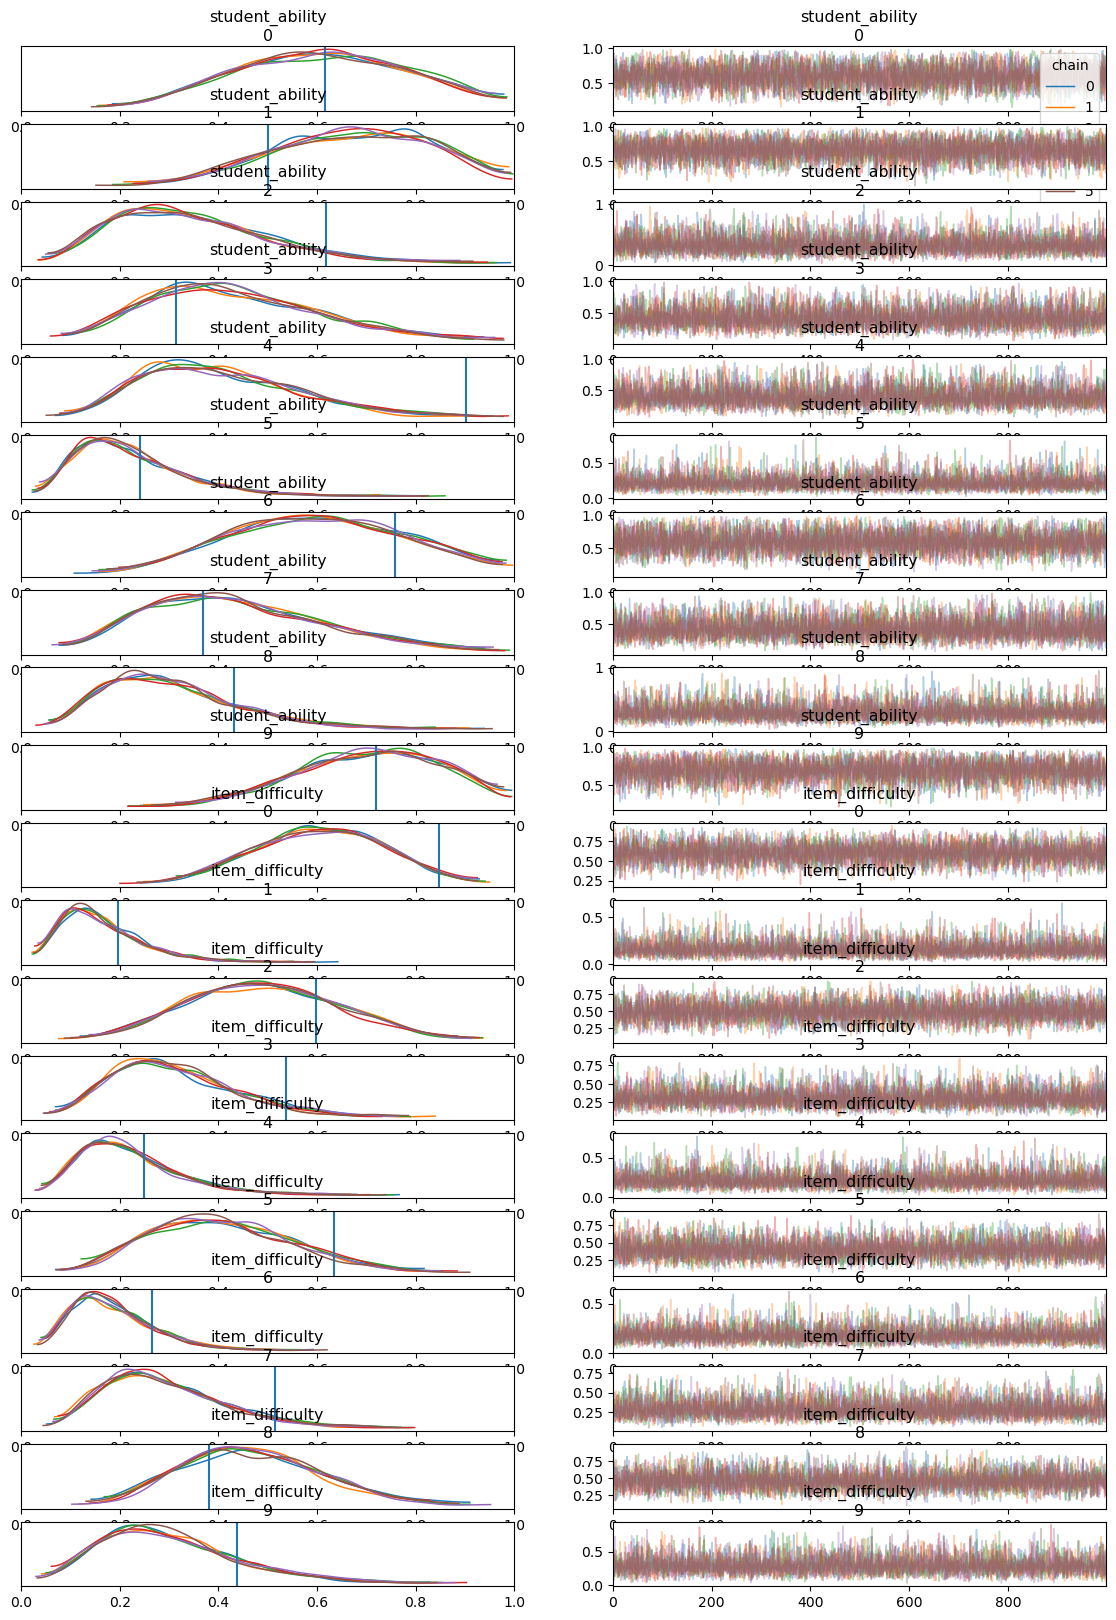

In [84]:
fig, axes = show_trace(trace, (2, 20))
rvals = np.concatenate([perf, diff], axis=0)
print(rvals)
for i in range(0, len(rvals)):
    axes[i * 2].axvline(rvals[i])
plt.tight_layout()
plt.show()